# Izbor instanci podataka - Praktican deo

## Ucitavanje i osnovna analiza skupa podataka
Prvo je potrebno ucitati podatke iz dataset-a Wine Quality i izvrsiti osnovnu analiza strukture podataka, tipovi atributa i ukupnog broja instanci.

In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings('ignore')

In [15]:
df = pd.read_csv('data/winequality-red.csv')

print("Dimenzije skupa podataka: ", df.shape)
df.head()

Dimenzije skupa podataka:  (1599, 12)


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5


## Dimenzije skupa podataka
Proveravamo tipove podataka i nedostajuce vrednosti. Tipovi su bitni jer k-NN zahteva numericke atribute, a nedostajuce vrednosti bi morale da se imputuju pre primene bilo kog algoritma zasnovanog na rastojanju.

In [ ]:
print(f"Tipovi podataka:")
print(df.dtypes)
print(f"\nNedostajuce vrednosti po atributu:")
print(df.isnull().sum())
print(f"\nUkupno nedostajućih vrednosti: {df.isnull().sum().sum()}")

Tipovi podataka:
fixed acidity           float64
volatile acidity        float64
citric acid             float64
residual sugar          float64
chlorides               float64
free sulfur dioxide     float64
total sulfur dioxide    float64
density                 float64
pH                      float64
sulphates               float64
alcohol                 float64
quality                   int64
dtype: object

Nedostajuće vrednosti po atributu:
fixed acidity           0
volatile acidity        0
citric acid             0
residual sugar          0
chlorides               0
free sulfur dioxide     0
total sulfur dioxide    0
density                 0
pH                      0
sulphates               0
alcohol                 0
quality                 0
dtype: int64

Ukupno nedostajućih vrednosti: 0


## Osnovna statistika numerickih atributa
Prikaz osnovnih statistickih mera (srednja vrednost, standardna devijacija, minimum, maksimum i kvartili) daje uvid u raspodelu atributa i njihove opsege vrednosti, sto je bitno jer k-NN koristi Euklidsko rastojanje i atributi sa vecim opsegom bi dominirali nad ostalima.

In [17]:
df.describe().round(2)

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
count,1599.00,1599.00,1599.00,1599.00,1599.00,1599.00,1599.00,1599.00,1599.00,1599.00,1599.00,1599.00
mean,8.32,0.53,0.27,2.54,0.09,15.87,46.47,1.00,3.31,0.66,10.42,5.64
std,1.74,0.18,0.19,1.41,0.05,10.46,32.90,0.00,0.15,0.17,1.07,0.81
min,4.60,0.12,0.00,0.90,0.01,1.00,6.00,0.99,2.74,0.33,8.40,3.00
25%,7.10,0.39,0.09,1.90,0.07,7.00,22.00,1.00,3.21,0.55,9.50,5.00
50%,7.90,0.52,0.26,2.20,0.08,14.00,38.00,1.00,3.31,0.62,10.20,6.00
75%,9.20,0.64,0.42,2.60,0.09,21.00,62.00,1.00,3.40,0.73,11.10,6.00
max,15.90,1.58,1.00,15.50,0.61,72.00,289.00,1.00,4.01,2.00,14.90,8.00


## Distribucija ciljne promenljive
Analiza distribucije klasa je kljucna za selekciju instanci. Nebalansiranost klasa direktno utice na k-NN jer ako vecina instanci pripada jednoj klasi, vecina najblizih suseda ce uvek biti iz te klase, sto dovodi do pristrasne klasifikacije.

Distribucija klasa (quality):
quality
3     10
4     53
5    681
6    638
7    199
8     18
Name: count, dtype: int64

Procentualna zastupljenost:
quality
3     0.6
4     3.3
5    42.6
6    39.9
7    12.4
8     1.1
Name: proportion, dtype: float64


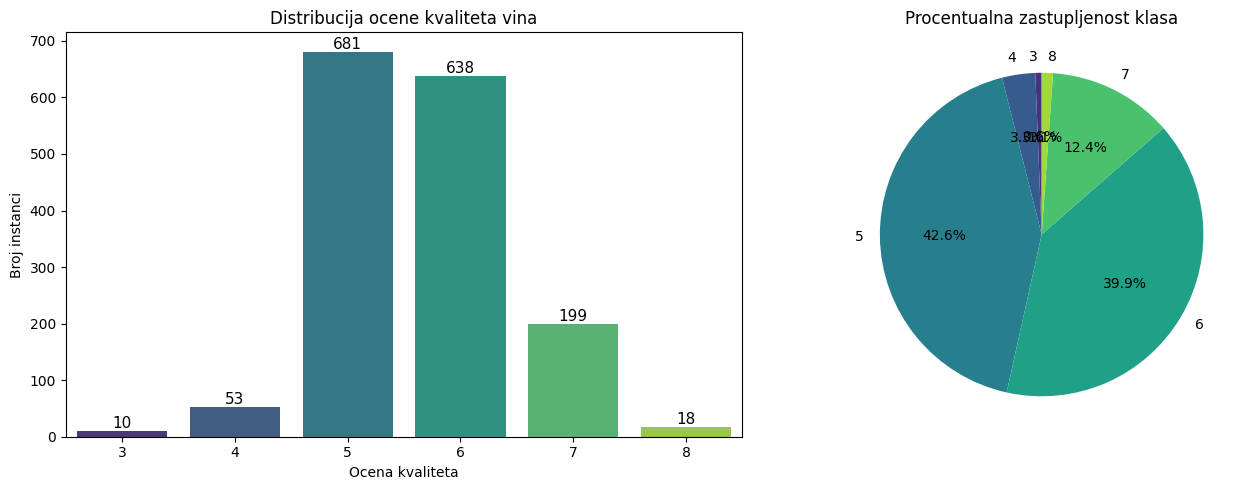

In [21]:
print("Distribucija klasa (quality):")
print(df['quality'].value_counts().sort_index())
print(f"\nProcentualna zastupljenost:")
print((df['quality'].value_counts(normalize=True).sort_index() * 100).round(1))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.countplot(x='quality', data=df, palette='viridis', ax=axes[0])
axes[0].set_title('Distribucija ocene kvaliteta vina')
axes[0].set_xlabel('Ocena kvaliteta')
axes[0].set_ylabel('Broj instanci')
for p in axes[0].patches:
    axes[0].annotate(f'{int(p.get_height())}', 
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='bottom', fontsize=11)
axes[1].pie(df['quality'].value_counts().sort_index(),
            labels=df['quality'].value_counts().sort_index().index,
            autopct='%1.1f%%',
            colors=sns.color_palette('viridis', 6),
            startangle=90)
axes[1].set_title('Procentualna zastupljenost klasa')

plt.tight_layout()
plt.show()

Distribucija pokazuje izrazitu nebalansiranost klasa. Klase 5 i 6 zajedno cine oko 82.5% svih instanci (681 + 638 = 1319), dok klase 3 i 8 imaju samo 10 i 18 primeraka. Ovo je klasican primer nebalansiranosti koji direktno utice na k-NN klasifikator. Vecina najblizih suseda nove instance ce gotovo uvek pripadati klasama 5 ili 6, sto znaci da ce retke klase biti sistematski pogresno klasifikovane.

Sa 6 klasa od kojih neke imaju manje od 20 instanci, klasifikacija bi bila nepouzdana. Zbog toga cemo grupisati ocene u tri kategorije: los kvalitet (3-5), srednji kvalitet (6) i dobar kvalitet (7-8), cime dobijamo manji broj klasa sa dovoljnim brojem instanci u svakoj za smislenu primenu selekcije instanci.

## Grupisanje klasa
Posto originalni dataset ima 6 klasa od kojih neke imaju manje od 20 instanci, grupisemo ocene u tri kategorije kako bismo dobili dovoljno primeraka u svakoj klasi za pouzdanu klasifikaciju i smislenu primenu metoda selekcije instanci.

Distribucija grupisanih klasa:
quality_class
0    744
1    638
2    217
Name: count, dtype: int64

Procentualna zastupljenost:
quality_class
0    46.5
1    39.9
2    13.6
Name: proportion, dtype: float64


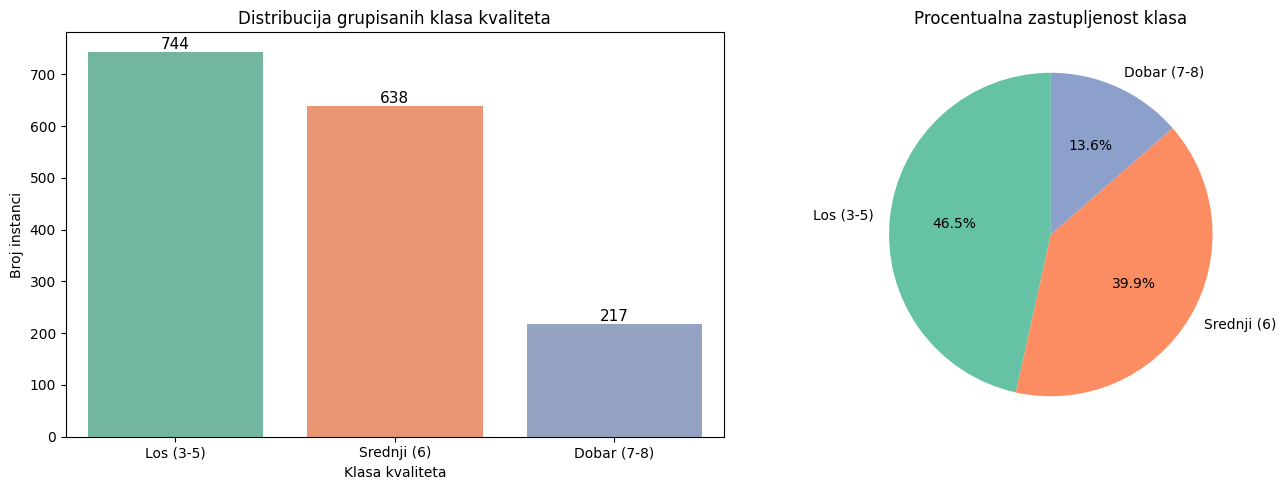

In [22]:
def map_quality(q):
    if q <= 5:
        return 0  # Los kvalitet
    elif q == 6:
        return 1  # Srednji kvalitet
    else:
        return 2  # Dobar kvalitet

df['quality_class'] = df['quality'].apply(map_quality)

print("Distribucija grupisanih klasa:")
print(df['quality_class'].value_counts().sort_index())
print(f"\nProcentualna zastupljenost:")
print((df['quality_class'].value_counts(normalize=True).sort_index() * 100).round(1))

labels = ['Los (3-5)', 'Srednji (6)', 'Dobar (7-8)']

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = sns.countplot(x='quality_class', data=df, palette='Set2', ax=axes[0])
ax.set_xticklabels(labels)
axes[0].set_title('Distribucija grupisanih klasa kvaliteta')
axes[0].set_xlabel('Klasa kvaliteta')
axes[0].set_ylabel('Broj instanci')
for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}', 
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='bottom', fontsize=11)

axes[1].pie(df['quality_class'].value_counts().sort_index(), 
            labels=labels,
            autopct='%1.1f%%', 
            colors=sns.color_palette('Set2', 3),
            startangle=90)
axes[1].set_title('Procentualna zastupljenost klasa')

plt.tight_layout()
plt.show()

Nakon grupisanja imamo tri klase: los kvalitet sa 744 instance (46.5%), srednji sa 638 (39.9%) i dobar sa 217 (13.6%). Klase su i dalje nebalansirane. Klasa 2 (dobar kvalitet) ima skoro 3.5 puta manje instanci od klase 0, sto znaci da ce k-NN i dalje teziti da favorizuje klase 0 i 1. Medjutim, sada svaka klasa ima dovoljno instanci za pouzdanu klasifikaciju i evaluaciju metoda selekcije instanci.

## Distribucije atributa
Vizualizacija distribucija svih numerickih atributa pomaze da se identifikuju outlieri i asimetricne distribucije. Ovo je relevantno za selekciju instanci jer outlieri i instance sa ekstremnim vrednostima su upravo one koje edition metode poput ENN ciljaju za uklanjanje.

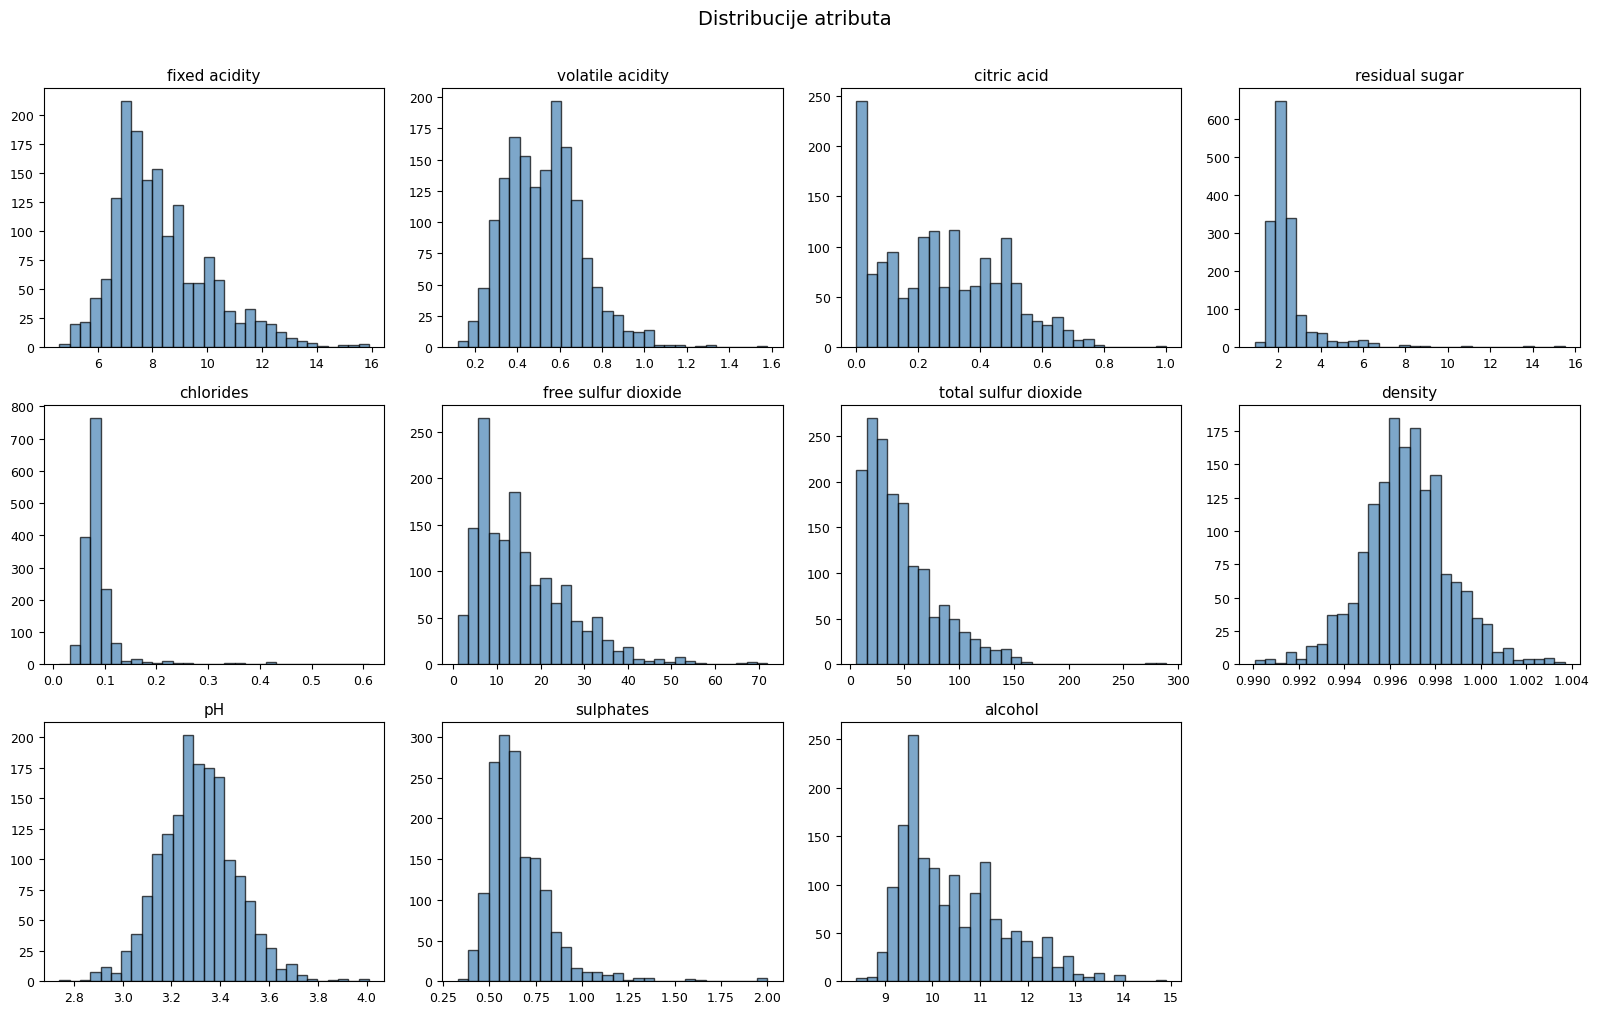

In [23]:
features = df.columns[:-2]

fig, axes = plt.subplots(3, 4, figsize=(16, 10))
axes = axes.flatten()

for i, col in enumerate(features):
    axes[i].hist(df[col], bins=30, color='steelblue', edgecolor='black', alpha=0.7)
    axes[i].set_title(col, fontsize=11)
    axes[i].tick_params(labelsize=9)

axes[-1].set_visible(False)
plt.suptitle('Distribucije atributa', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

Vecina atributa ima asimetricnu distribuciju sa desnim repom, posebno `residual sugar`, `chlorides`, `sulphates` i `total sulfur dioxide`. Dugi repovi ukazuju na prisustvo outliera, instanci sa ekstremnim vrednostima koje se nalaze daleko od centra distribucije. Atributi `pH` i `density` imaju priblizno normalnu distribuciju. Ovi outlieri su potencijalni kandidati za uklanjanje edition metodama jer se cesto nalaze u blizini instanci druge klase i mogu negativno uticati na k-NN klasifikaciju.

## Korelaciona matrica
Analiza korelacija izmedju atributa pomaze da se razume struktura podataka i identifikuju potencijalno redundantni atributi koji ne doprinose dodatnim informacijama za klasifikaciju.

In [ ]:
plt.figure(figsize=(12, 9))
sns.heatmap(df[features].corr(), annot=True, fmt='.2f', cmap='coolwarm', 
            center=0, square=True, linewidths=0.5)
plt.title('Korelaciona matrica atributa', fontsize=14)
plt.tight_layout()
plt.show()